# **Evaluating Traditional Machine Learning Models for Heart Disease Prediction**

### Import needed packages
 - NumPy
 - Matplotlib
 - seaborn
 - Pandas
 - Scikit-learn


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn import metrics
%matplotlib inline

## Download & Understand the data

### `heart_disease_data.csv`:
You will download and use a Heart-Disease-UCI dataset, **`heart_disease_data.csv`**, which contains **`606 patient records`** each representing an individual who underwent a series of clinical and diaagnostic examinations related to cardiovascular. [Dataset source](https://www.kaggle.com/datasets/thisishusseinali/uci-heart-disease-data)

* **age:** The person's age in years
* **sex:** The person's sex (1 = male, 0 = female)
* **cp:** The chest pain experienced (Value 0: typical angina, Value 1: atypical angina, Value 2: non-anginal pain, Value 3: asymptomatic)
* **trestbps:** The person's resting blood pressure (mm Hg on admission to the hospital)
* **chol:** The person's cholesterol measurement in mg/dl
* **fbs:** The person's fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
* **restecg:** Resting electrocardiographic measurement (0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria)
* **thalach:** The person's maximum heart rate achieved
* **exang:** Exercise induced angina (1 = yes; 0 = no)
* **oldpeak:** ST depression induced by exercise relative to rest ('ST' relates to positions on the ECG plot. See more here)
* **slope:** the slope of the peak exercise ST segment (Value 0: upsloping, Value 1: flat, Value 2: downsloping)
* **ca:** The number of major vessels (0-3)
* **thal:** A blood disorder called thalassemia (0 = null; 1 = fixed defect; 2 = normal; 3 = reversable defect)
* **target: Heart disease (0 = no, 1 = yes)**

The task will be to create a compartive between ML models using some of these features to predict heart diease based on the selected features. 

In [2]:
path = 'heart_disease_data.csv'
data = pd.read_csv(path)


In [3]:
data.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
248,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
506,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
572,44,1,0,110,197,0,0,177,0,0.0,2,1,2,0
492,66,1,0,112,212,0,0,132,1,0.1,2,1,2,0
412,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1


## Dataset Analysis

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       606 non-null    int64  
 1   sex       606 non-null    int64  
 2   cp        606 non-null    int64  
 3   trestbps  606 non-null    int64  
 4   chol      606 non-null    int64  
 5   fbs       606 non-null    int64  
 6   restecg   606 non-null    int64  
 7   thalach   606 non-null    int64  
 8   exang     606 non-null    int64  
 9   oldpeak   606 non-null    float64
 10  slope     606 non-null    int64  
 11  ca        606 non-null    int64  
 12  thal      606 non-null    int64  
 13  target    606 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 66.4 KB


* > we observe after using `info()` function:
* That all cols are complete with no missing values
* Name of cols are consistant 
* we don't need for transformaing & encoding data (as each number already represents a specefice category) 

In [5]:
print("""
Sex : {}
Cp : {}
Fbs : {}
Restecg : {}
Exang : {}
Slope : {}
Ca : {}
Thal : {}
""".format(data.sex.unique(),
           data.cp.unique(),
           data.fbs.unique(),
           data.restecg.unique(),
           data.exang.unique(),
           data.slope.unique(),
           data.ca.unique(),
           data.thal.unique()))


Sex : [1 0]
Cp : [0 2 3 1]
Fbs : [1 0]
Restecg : [0 1 2]
Exang : [1 0]
Slope : [2 1 0]
Ca : [2 1 0 3 4]
Thal : [3 2 1 0]



**`Representation of Categorical Data`**
* sex: 0 -> female, 1 -> male 
* cp : 0 -> typical angina, 1 -> atypical angina, 2 -> non-anginal pain, 3 -> asymptomatic
* fbs : 0 -> false, 1 -> true
* Restecg : 0 -> normal, 1-> ST_T wave abnormality, 2 -> left ventricular hypertrophy
* Exang: exercies induced angina (0-> no, 1 -> yes)
* slope: 0 -> upsloping , 1-> flat , 2-> downsloping
* thal : 0 -> null , 1 -> fixed defect, 2 -> normal , 3-> reversible defect

In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.074592,0.465626,1.031199,17.523642,51.787898,0.355903,0.525425,22.886223,0.469406,1.160115,0.615717,1.021761,0.611770,0.498422
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.250000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


No. of samples on each category

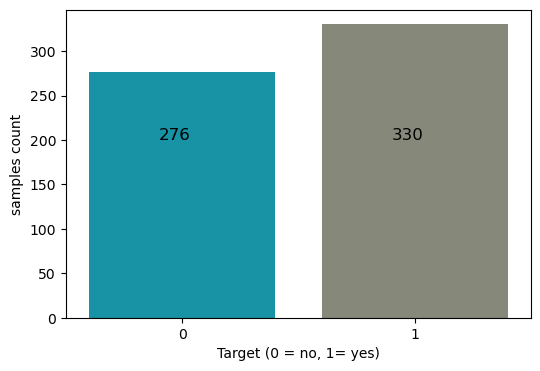

In [7]:
count_No = len(data[data.target == 0]) 
count_yes = len(data[data.target == 1])
list1 = [count_No, count_yes]
color = ["#00a3bc","#888b77"]
plt.figure(figsize=(6,4))
sns.countplot(x="target",
              data=data,
              palette=color)
plt.ylabel("samples count")
plt.xlabel("Target (0 = no, 1= yes)")

for line in range(2):
          plt.text(line-0.1, # x
                200, # y
                list1[line], 
                horizontalalignment='left',
               fontsize=12,
               color="black",
               )

plt.savefig('samples-count.png',transparent=True)

plt.show()

not diagnosis : 45.54%
have diagnosis : 54.46%


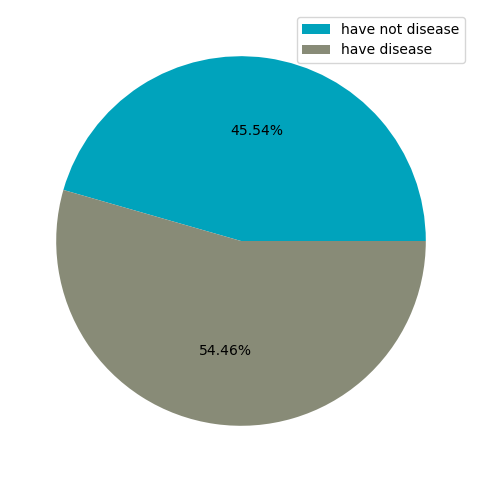

In [8]:

print("not diagnosis : {:.2f}%".format((count_No / (len(data.target))*100)))
print("have diagnosis : {:.2f}%".format((count_yes / (len(data.target))*100)))

plt.figure(figsize=(6,6))
plt.pie([count_No,count_yes],
        colors=color,
        autopct='%1.2f%%')

plt.legend(labels=["have not disease","have disease"])

plt.savefig('pie-count.png',transparent=True)

In [9]:
data.shape

(606, 14)

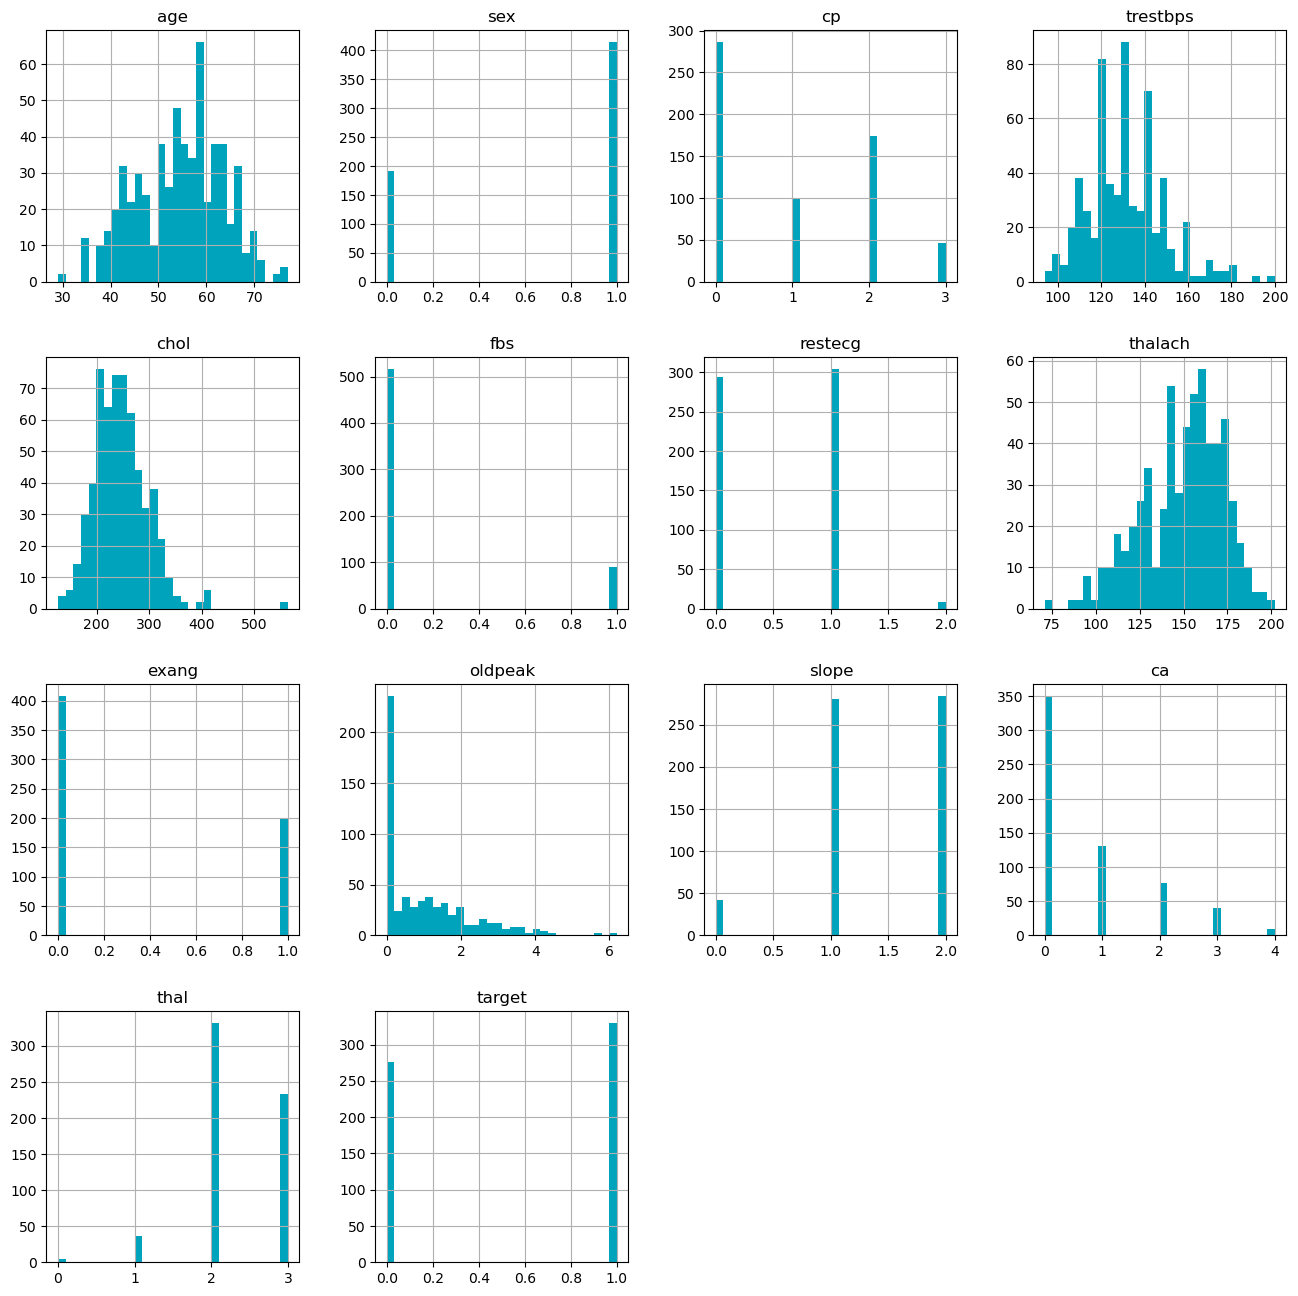

In [10]:
data.hist(bins= 30, color='#00a3bc', figsize=(16,16))
plt.show()

After observation, we noticed a slight imbalance between the classes. Therfore, we balance the data using **`SMOT`** technique, which
generates synthetic sampls for the minority class to match the size of the other class.

## **Data augmentation** (Random Sampling)
> * *`resampling()`* from sklearn.utils import resample

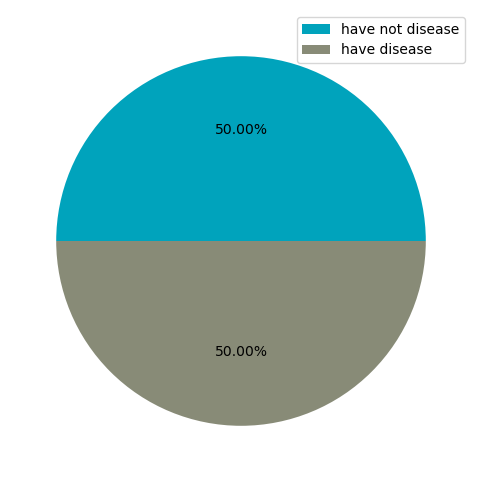

In [11]:
df_0 = data[data['target'] == 0]
df_1 = data[data['target'] == 1]

count_1 = df_1['target'].count()

df_upsample_0 = resample(df_0 , n_samples= count_1)

data = pd.concat([df_upsample_0 , df_1])


count_val = data['target'].value_counts()

plt.figure(figsize=(6,6))
plt.pie([count_val[0], count_val[1]],
        colors=color,
        autopct='%1.2f%%')

plt.legend(labels=["have not disease","have disease"])


In [12]:
print(data[data['target'] == 0].shape)
print(data[data['target'] == 1].shape)

(330, 14)
(330, 14)


# **Featres Engineering**

* ## **Features Selection**

* # **1. MI** Mutual Information:
Measure the amount of info. shared between each featre and the target variable.
 In other words,it shows how well a feature can predict the class.
  The feature with **high MI** are consider more important for the model.
  > from sklearn.feature_selection import  `mutual_info_classif`

In [13]:
from sklearn.feature_selection import mutual_info_classif

x = data.iloc[:,:-1]
y = data['target']

mi = mutual_info_classif(x,y)
mi_series = pd.Series(mi, index= x.columns).sort_values(ascending=False)
mi_series


chol        0.266608
thal        0.163022
oldpeak     0.155429
thalach     0.151631
ca          0.120884
cp          0.111540
exang       0.100656
age         0.096800
slope       0.072897
trestbps    0.054102
sex         0.053536
fbs         0.005645
restecg     0.000000
dtype: float64

* # **2. RFE** Recursive Feature Elimination:

Select the most important features recursively by fitting a model and removing the least important features step by step until the optimal set of features is obtaind.
> from sklearn.feature_selection import `RFE` 

In [14]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=15)
rfe = RFE(model,n_features_to_select=7)  # Select top 7 features
rfe = rfe.fit(x, y)

for col,rank in zip(x.columns, rfe.support_):
    if rank:
        print(col)

sex
cp
exang
oldpeak
slope
ca
thal


C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

* # **3. Features Correlation**:
Calculate the linear relationship between each feature and the target variable using corr. cofficients (pearson).
Feature with high `corr. with the target` are consider more useful, while low-corr features can be ignored to reduce complexity and noise in the data.

In [15]:
corr = data.corr()
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.106914,-0.047913,0.334652,0.225611,0.165327,-0.121426,-0.366926,0.056954,0.164975,-0.133486,0.300899,0.080362,-0.224046
sex,-0.106914,1.000000,-0.034879,-0.064165,-0.252297,0.037305,-0.050430,-0.039833,0.129368,0.117275,-0.038159,0.107180,0.238452,-0.275411
cp,-0.047913,-0.034879,1.000000,0.064851,-0.075228,0.104631,-0.021044,0.320070,-0.369008,-0.147889,0.078540,-0.171272,-0.175597,0.418464
trestbps,0.334652,-0.064165,0.064851,1.000000,0.154462,0.198326,-0.094537,-0.080401,0.097030,0.176433,-0.092099,0.103125,0.030497,-0.154779
chol,0.225611,-0.252297,-0.075228,0.154462,1.000000,0.048149,-0.163562,-0.010650,0.047954,0.104233,0.002208,0.119702,0.099024,-0.091561
fbs,0.165327,0.037305,0.104631,0.198326,0.048149,1.000000,-0.126541,-0.005084,0.016732,-0.026127,-0.036446,0.162607,-0.059028,-0.049903
restecg,-0.121426,-0.050430,-0.021044,-0.094537,-0.163562,-0.126541,1.000000,0.000083,0.020509,0.018354,0.020479,-0.059366,0.024812,0.086217
thalach,-0.366926,-0.039833,0.320070,-0.080401,-0.010650,-0.005084,0.000083,1.000000,-0.354609,-0.360242,0.380026,-0.212527,-0.126190,0.422544
exang,0.056954,0.129368,-0.369008,0.097030,0.047954,0.016732,0.020509,-0.354609,1.000000,0.353742,-0.247596,0.084041,0.229166,-0.436078
oldpeak,0.164975,0.117275,-0.147889,0.176433,0.104233,-0.026127,0.018354,-0.360242,0.353742,1.000000,-0.550101,0.239784,0.234497,-0.440055


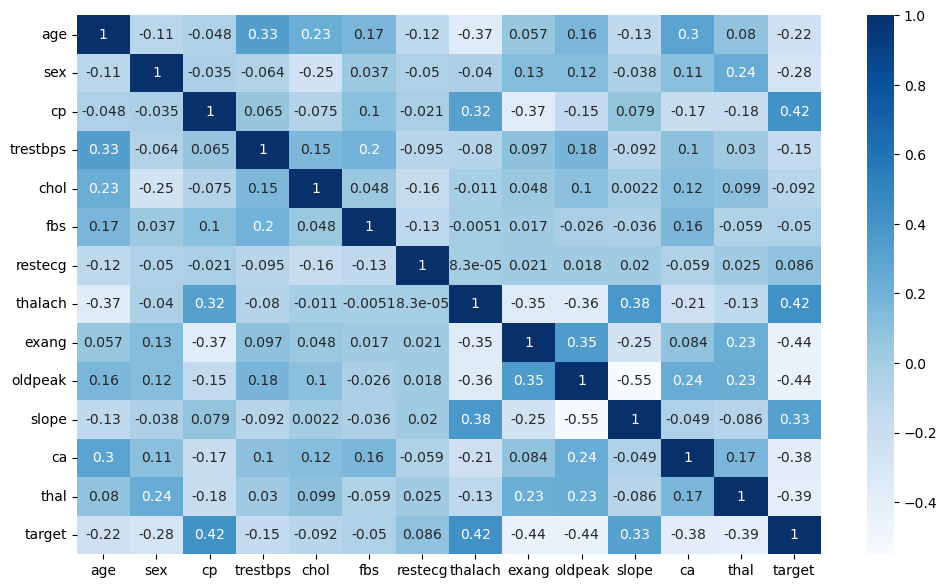

In [16]:
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True , cmap='Blues')
plt.show()

<AxesSubplot:>

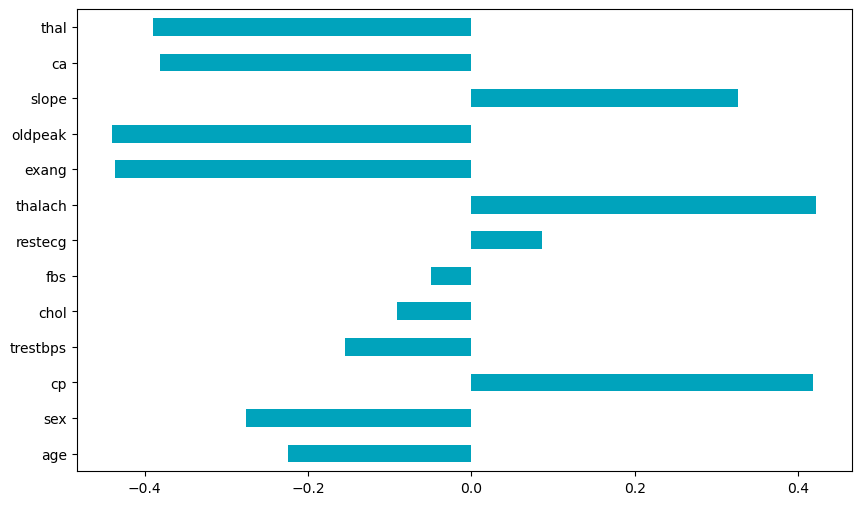

In [17]:
correlation_values = data.corr()['target'].drop('target')
correlation_values.plot(kind='barh', figsize=(10, 6), color='#00a3bc')

# **Features selection via correlation**

In [18]:
x = np.asarray(data[['cp','thalach', 'slope', 'exang', 'oldpeak', 'ca', 'thal']])
y = np.asarray(data['target'])
y.shape
# x_input = data.drop(data['target'])
# y_output = data['target']

(660,)

# **Data Preprocessing**
* ## **Features Scaling**

x with MinMaxScaler `Normalization`

In [19]:
x_MinMax = MinMaxScaler().fit_transform(x)

x with StandardScaler `Standardization`

In [20]:
x_Standard = StandardScaler().fit_transform(x)

Data Split `(Normalization Data)`

In [21]:
x_train_N, x_test_N, y_train_N, y_test_N = train_test_split(x_MinMax, y , test_size=0.2, random_state=46)

Data Split `(Standarded Data)`

In [22]:
x_train_S, x_test_S, y_train_S, y_test_S = train_test_split(x_Standard, y , test_size=0.2, random_state=46)

# **1 Logistic Regression** 

Logistic Regression Training With MinMaxScaler

In [23]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train_N,y_train_N)

LogisticRegression()

In [24]:
y_pred = LR.predict(x_test_N)
y_prop = LR.predict_proba(x_test_N)

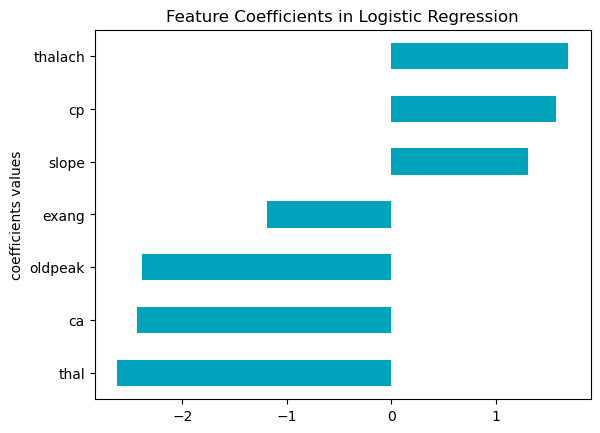

In [25]:
coefficients = pd.Series(LR.coef_[0], index= ['cp','thalach', 'slope', 'exang', 'oldpeak', 'ca', 'thal'])
coefficients.sort_values().plot(kind='barh', color ='#00a3bc')
plt.title("Feature Coefficients in Logistic Regression")
plt.ylabel('coefficients values')
plt.show()

**Logistic Regression Model Evaluation** with Normalization Scaleing

In [26]:
from sklearn.metrics import log_loss
loss = round(log_loss(y_test_N, y_prop), 2)
loss

0.38

In [27]:
accuracy = round(metrics.accuracy_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_N , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_N , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  81.82
Accuracy score:  78.79
Accuracy score:  83.87
f1_scor :  81.25


In [28]:
config = metrics.confusion_matrix(y_test_N, y_pred)
config

array([[56, 14],
       [10, 52]], dtype=int64)

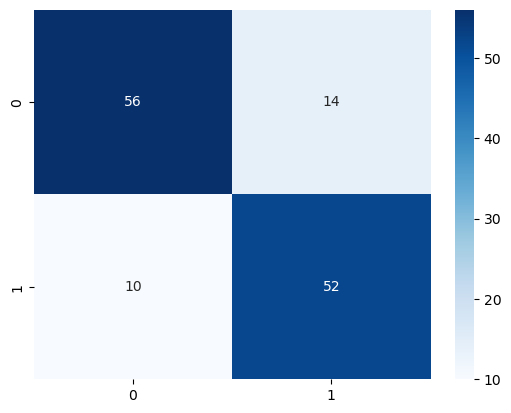

In [29]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [30]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_norm = pd.DataFrame(row , index=['LR'])
df_norm

,ACC,Precision,recall,f1_score
LR,81.82,78.79,83.87,81.25


Logistic Regression Training With Standardaization

In [31]:
LR = LogisticRegression()
LR.fit(x_train_S,y_train_S)

LogisticRegression()

In [32]:
y_pred = LR.predict(x_test_S)
y_prop = LR.predict_proba(x_test_S)

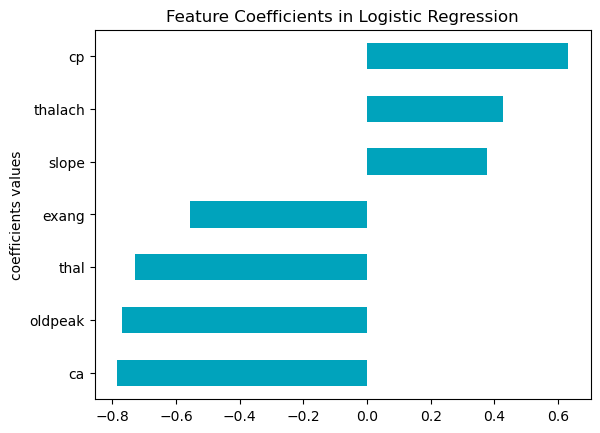

In [33]:
coefficients = pd.Series(LR.coef_[0], index= ['cp','thalach', 'slope', 'exang', 'oldpeak', 'ca', 'thal'])
coefficients.sort_values().plot(kind='barh', color= '#00a3bc')
plt.title("Feature Coefficients in Logistic Regression")
plt.ylabel('coefficients values')
plt.show()

**Logistic Regression Model Evaluation** with Standardization Scaleing

In [34]:
loss = round(log_loss(y_test_S, y_prop), 2)
loss

0.37

In [35]:
accuracy = round(metrics.accuracy_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_S , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_S , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  85.61
Accuracy score:  84.13
Accuracy score:  85.48
f1_scor :  84.8


In [36]:
config = metrics.confusion_matrix(y_test_S, y_pred)
config

array([[60, 10],
       [ 9, 53]], dtype=int64)

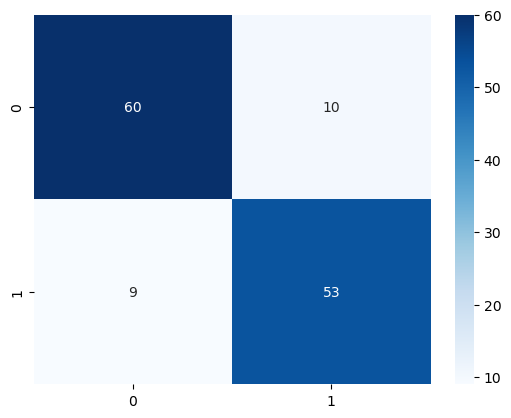

In [37]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [38]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_s = pd.DataFrame(row , index=['LR'])
df_s

,ACC,Precision,recall,f1_score
LR,85.61,84.13,85.48,84.8


## **2. Nive Bayes**

Naive Bayes Training with Normalaization

In [39]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB.fit(x_train_N,y_train_N)

GaussianNB()

In [40]:
y_pred = NB.predict(x_test_N)
y_prop = NB.predict_proba(x_test_N)

**Nive Bayes Model Evaluation** with Normalization Scaleing

In [41]:
loss = round(log_loss(y_test_N, y_prop), 2)
loss

0.65

In [42]:
accuracy = round(metrics.accuracy_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_N , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_N , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  77.27
Accuracy score:  76.67
Accuracy score:  74.19
f1_scor :  75.41


In [43]:
config = metrics.confusion_matrix(y_test_N, y_pred)
config

array([[56, 14],
       [16, 46]], dtype=int64)

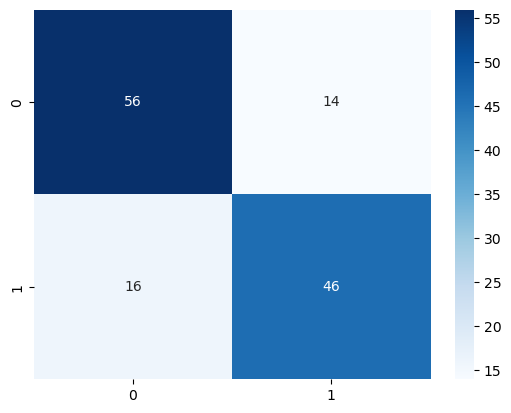

In [44]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [45]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_n2 = pd.DataFrame(row, index=['NB'])
df_n2

,ACC,Precision,recall,f1_score
NB,77.27,76.67,74.19,75.41


Naive Bayes Training with Standardization

In [46]:
NB = GaussianNB()
NB.fit(x_train_S,y_train_S)

GaussianNB()

In [47]:
y_pred = NB.predict(x_test_S)
y_prop = NB.predict_proba(x_test_S)

**Nive Bayes Model Evaluation** with Normalization Scaleing

In [48]:
loss = round(log_loss(y_test_S, y_prop), 2)
loss

0.65

In [49]:
accuracy = round(metrics.accuracy_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_S , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_S , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  77.27
Accuracy score:  76.67
Accuracy score:  74.19
f1_scor :  75.41


In [50]:
config = metrics.confusion_matrix(y_test_S, y_pred)
config

array([[56, 14],
       [16, 46]], dtype=int64)

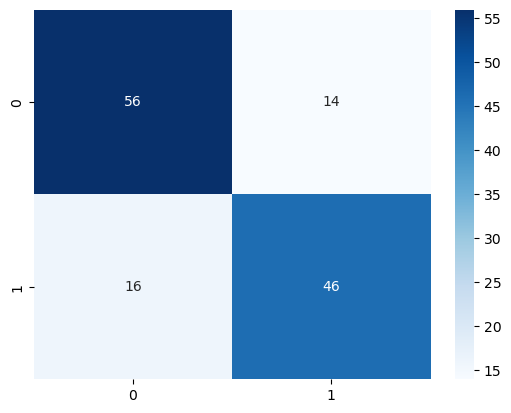

In [51]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [52]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_s2 = pd.DataFrame(row, index=['NB'])
df_s2

,ACC,Precision,recall,f1_score
NB,77.27,76.67,74.19,75.41


## **3. Decision Tree**

Decision Tree model Training with Normalization

In [53]:
value = [i for i in range(1,21)]

In [54]:
train_score, test_score = list(), list()

In [55]:
from sklearn.tree import DecisionTreeClassifier ,plot_tree

for i in value:
    DT = DecisionTreeClassifier(criterion='entropy', max_depth=i, random_state= 42)
    DT.fit(x_train_N, y_train_N)

    train_yhat = DT.predict(x_train_N)
    train_acc = metrics.accuracy_score(y_train_N, train_yhat)
    train_score.append(train_acc)

    tes_yhat = DT.predict(x_test_N)
    test_acc = metrics.accuracy_score(y_test_N, tes_yhat)
    test_score.append(test_acc)

    print('%d, train: %.3f, test: %.3f'% (i, train_acc*100, test_acc*100))

1, train: 77.083, test: 74.242
2, train: 77.462, test: 81.818
3, train: 84.848, test: 87.121
4, train: 87.879, test: 85.606
5, train: 89.394, test: 90.909
6, train: 92.803, test: 90.909
7, train: 94.508, test: 93.182
8, train: 97.727, test: 93.182
9, train: 99.053, test: 96.212
10, train: 99.621, test: 96.970
11, train: 99.811, test: 96.212
12, train: 100.000, test: 96.212
13, train: 100.000, test: 96.212
14, train: 100.000, test: 96.212
15, train: 100.000, test: 96.212
16, train: 100.000, test: 96.212
17, train: 100.000, test: 96.212
18, train: 100.000, test: 96.212
19, train: 100.000, test: 96.212
20, train: 100.000, test: 96.212


In [56]:
len(train_score)

20

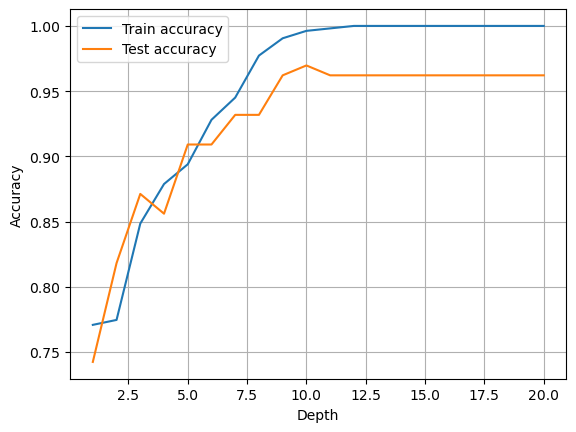

In [57]:

plt.plot(value, train_score, label='Train accuracy')
plt.plot(value, test_score, label='Test accuracy')

plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
DT = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state= 4)
DT.fit(x_train_N, y_train_N)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=4)

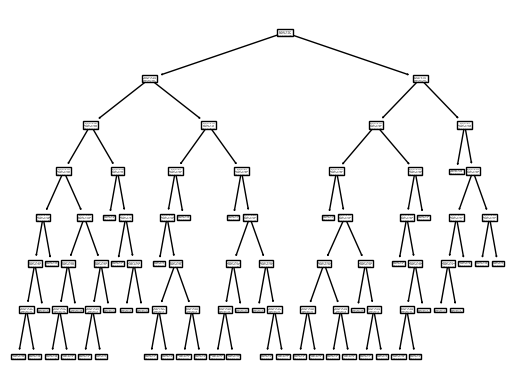

In [59]:
plot_tree(DT)
plt.show()

**DT model Evaluation** with normalization

In [60]:
y_pred = DT.predict(x_test_N)

In [61]:
accuracy = round(metrics.accuracy_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_N , y_pred)*100,2)
print('precision score: ', precision)
recall = round(metrics.recall_score(y_test_N , y_pred)*100,2)
print('recall score: ', recall)
f1_scor = round(metrics.f1_score(y_test_N , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_N , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  93.18
precision score:  89.55
recall score:  96.77
f1_scor :  93.02


In [62]:
config = metrics.confusion_matrix(y_test_N, y_pred)
config

array([[63,  7],
       [ 2, 60]], dtype=int64)

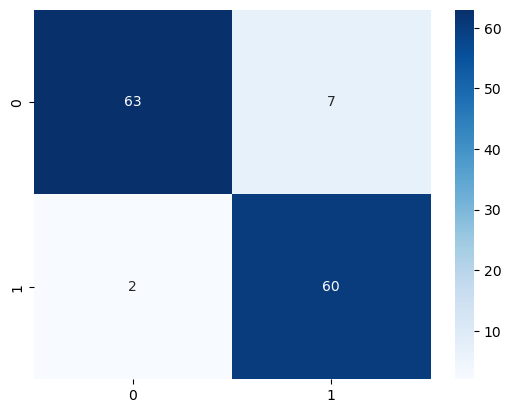

In [63]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [64]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_n3 = pd.DataFrame(row, index= ['DT'])
df_n3

,ACC,Precision,recall,f1_score
DT,93.18,89.55,96.77,93.02


Decision Tree model Training with Standardaization

In [65]:
value = [i for i in range(1,21)]

In [66]:
train_score, test_score = list(), list()

In [67]:
for i in value:
    DT = DecisionTreeClassifier(criterion='entropy', max_depth=i , random_state=42)
    DT.fit(x_train_S, y_train_S)

    train_yhat = DT.predict(x_train_S)
    train_acc = metrics.accuracy_score(y_train_S, train_yhat)
    train_score.append(train_acc)

    tes_yhat = DT.predict(x_test_S)
    test_acc = metrics.accuracy_score(y_test_S, tes_yhat)
    test_score.append(test_acc)

    print('%d, train: %.3f, test: %.3f'% (i, train_acc*100, test_acc*100))

1, train: 77.083, test: 74.242
2, train: 77.462, test: 81.818
3, train: 84.848, test: 87.121
4, train: 87.879, test: 85.606
5, train: 89.394, test: 90.909
6, train: 92.803, test: 90.909
7, train: 94.508, test: 93.182
8, train: 97.727, test: 93.182
9, train: 99.053, test: 96.212
10, train: 99.621, test: 96.970
11, train: 99.811, test: 96.212
12, train: 100.000, test: 96.212
13, train: 100.000, test: 96.212
14, train: 100.000, test: 96.212
15, train: 100.000, test: 96.212
16, train: 100.000, test: 96.212
17, train: 100.000, test: 96.212
18, train: 100.000, test: 96.212
19, train: 100.000, test: 96.212
20, train: 100.000, test: 96.212


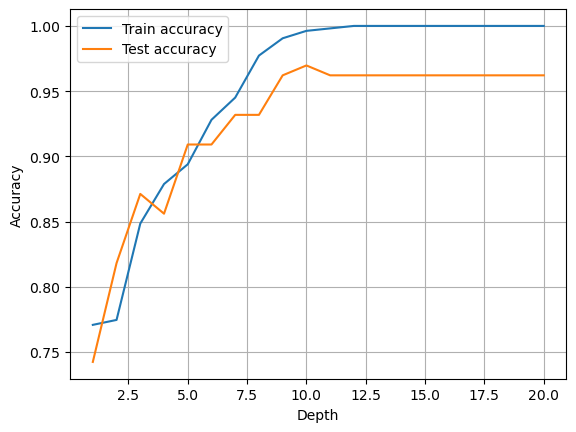

In [68]:
plt.plot(value, train_score, label='Train accuracy')
plt.plot(value, test_score, label='Test accuracy')

plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [69]:
DT = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state = 4)
DT.fit(x_train_S, y_train_S)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=4)

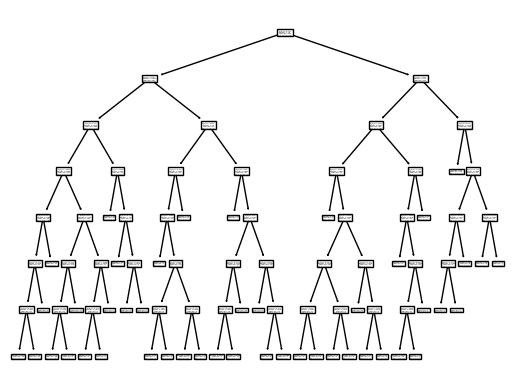

In [70]:
plot_tree(DT)
plt.show()

**DT model Evaluation** with Standardaization

In [71]:
y_pred = DT.predict(x_test_S)
y_proba = DT.predict_proba(x_test_S)

In [72]:
loss = round(log_loss(y_pred, y_proba), 2)
loss

0.07

In [73]:
accuracy = round(metrics.accuracy_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_S , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_S , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  93.18
Accuracy score:  89.55
Accuracy score:  96.77
f1_scor :  93.02


In [74]:
config = metrics.confusion_matrix(y_test_S, y_pred)
config

array([[63,  7],
       [ 2, 60]], dtype=int64)

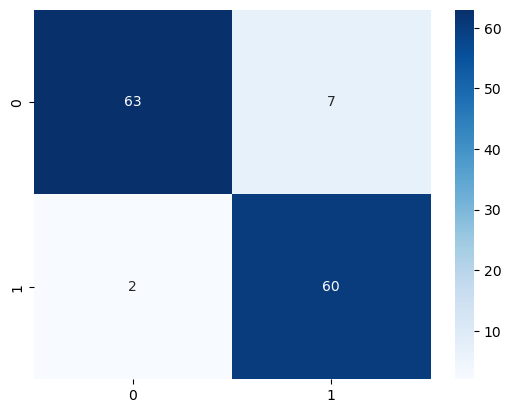

In [75]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [76]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor }
df_s3 = pd.DataFrame(row, index=['DT'])
df_s3

,ACC,Precision,recall,f1_score
DT,93.18,89.55,96.77,93.02


## **4. SVM**

Decision Tree model Training with Normalization

In [77]:
from sklearn.svm import SVC
svcM = SVC(kernel='rbf', C=1.0, gamma='scale')
svcM.fit(x_train_N, y_train_N)

SVC()

**SVM model Evaluation** with normalization

In [78]:
y_pred = svcM.predict(x_test_N)

In [79]:
# loss = round(log_loss(y_test_N, y_pred), 2)
# loss

In [80]:
accuracy = round(metrics.accuracy_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_N , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_N , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  84.85
Accuracy score:  85.0
Accuracy score:  82.26
f1_scor :  83.61


In [81]:
config = metrics.confusion_matrix(y_test_N, y_pred)
config

array([[61,  9],
       [11, 51]], dtype=int64)

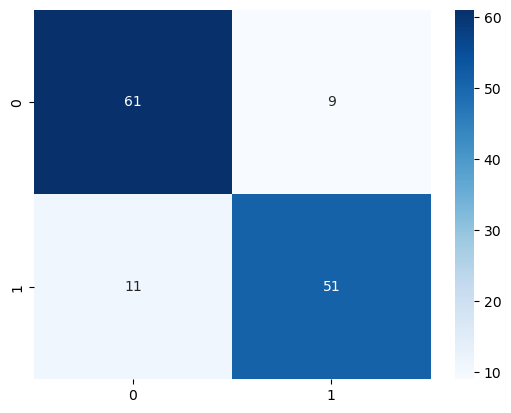

In [82]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [83]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_n4 = pd.DataFrame(row, index= ['SVM'])
df_n4

,ACC,Precision,recall,f1_score
SVM,84.85,85.0,82.26,83.61


SVM Tree model Training with Standardization

In [84]:
from sklearn.svm import SVC
svcM = SVC(kernel='rbf', C=1.0, gamma='scale')
svcM.fit(x_train_S, y_train_S)

SVC()

In [85]:
y_pred = svcM.predict(x_test_S)

In [86]:
accuracy = round(metrics.accuracy_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_S , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_S , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  86.36
Accuracy score:  83.33
Accuracy score:  88.71
f1_scor :  85.94


In [87]:
config = metrics.confusion_matrix(y_test_S, y_pred)
config

array([[59, 11],
       [ 7, 55]], dtype=int64)

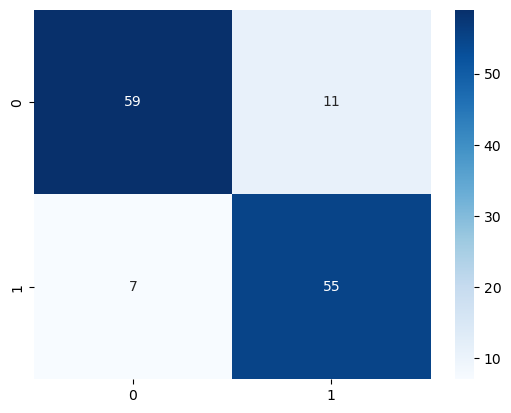

In [88]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [89]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_s4 = pd.DataFrame(row, index= ['SVM'])
df_s4

,ACC,Precision,recall,f1_score
SVM,86.36,83.33,88.71,85.94


# **5. KNN**

KNN model training with Normalaizition

In [90]:
# from sklearn.neighbors import KNeighborsClassifier
# scoreList = []
# for i in range(1,20):
#     knn2 = KNeighborsClassifier(n_neighbors = i)  
#     knn2.fit(x_train_N, y_train_N)
#     scoreList.append(knn2.score(x_test_N, y_test_N))
    
# plt.plot(range(1,20), scoreList)
# plt.xticks(np.arange(1,20,1))
# plt.xlabel("K value")
# plt.ylabel("score")
# plt.show()

# knn_score = max(scoreList)
# print("Maximum KNN Score is {:.2f}%".format((max(scoreList))*100))

In [91]:
from sklearn.neighbors import KNeighborsClassifier
Ks = 10
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(x_train_N, y_train_N)
    yhat = knn_model_n.predict(x_test_N)
    acc[n-1] = metrics.accuracy_score(y_test_N, yhat)
    std_acc[n-1] = np.std(yhat==y_test_N)/np.sqrt(yhat.shape[0])

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be 

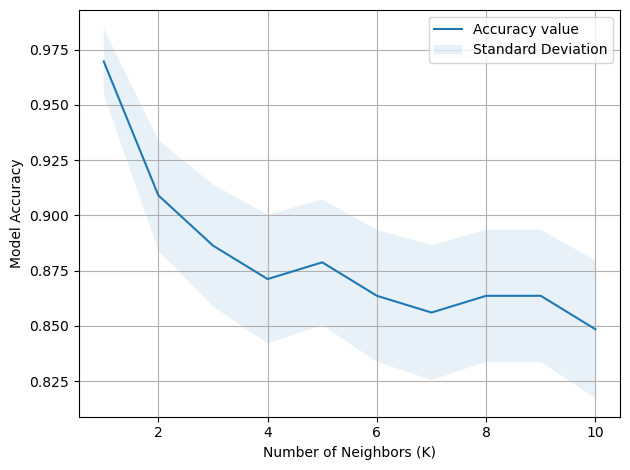

In [92]:
plt.plot(range(1,Ks+1),acc)

plt.fill_between(range(1,Ks+1), acc - 1 * std_acc, acc + 1 * std_acc, alpha=0.10)

plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.grid()
plt.show()

In [93]:
import math
k = int(math.sqrt(len(x_train_N)))
if k % 2 == 0:
    k+= 1

In [94]:


KNN = KNeighborsClassifier(n_neighbors=k)
KNN.fit(x_train_N, y_train_N)

KNeighborsClassifier(n_neighbors=23)

**KNN model Evaluation** with normalization

In [95]:
y_pred = KNN.predict(x_test_N)
k

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


23

In [96]:
accuracy = round(metrics.accuracy_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_N , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_N , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_N , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  82.58
Accuracy score:  78.26
Accuracy score:  87.1
f1_scor :  82.44


In [97]:
config = metrics.confusion_matrix(y_test_N, y_pred)
config

array([[55, 15],
       [ 8, 54]], dtype=int64)

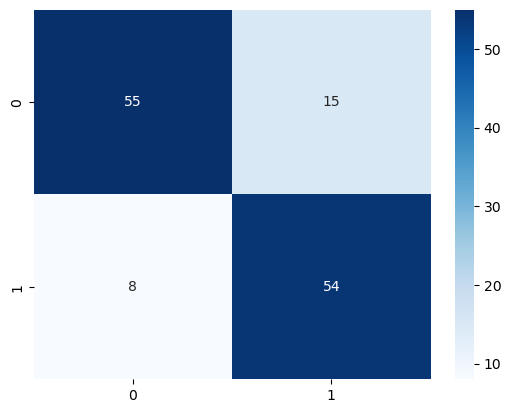

In [98]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [99]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_n5 = pd.DataFrame(row, index=['KNN'])
df_n5

,ACC,Precision,recall,f1_score
KNN,82.58,78.26,87.1,82.44


KNN model training with Standardazition

In [100]:
KNN = KNeighborsClassifier(n_neighbors=k)
KNN.fit(x_train_S, y_train_S)

KNeighborsClassifier(n_neighbors=23)

**KNN model Evaluation** with Standardazition

In [101]:
y_pred = KNN.predict(x_test_S)

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [102]:
accuracy = round(metrics.accuracy_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', accuracy)
precision = round(metrics.precision_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', precision)
recall = round(metrics.recall_score(y_test_S , y_pred)*100,2)
print('Accuracy score: ', recall)
f1_scor = round(metrics.f1_score(y_test_S , y_pred)*100,2)
print('f1_scor : ', f1_scor)
# roc_auc_score = round(metrics.roc_auc_score(y_test_S , y_pred)*100,2)
# print('roc_auc_score : ', roc_auc_score)

Accuracy score:  84.85
Accuracy score:  82.81
Accuracy score:  85.48
f1_scor :  84.13


In [103]:
config = metrics.confusion_matrix(y_test_S, y_pred)
config

array([[59, 11],
       [ 9, 53]], dtype=int64)

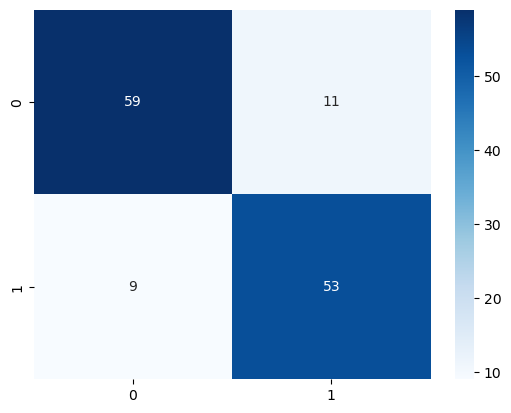

In [104]:
sns.heatmap(config, annot=True , cmap='Blues')
plt.show()

In [105]:
row = {
    "ACC": accuracy , "Precision": precision, "recall":recall, "f1_score": f1_scor
}
df_s5 = pd.DataFrame(row, index=['KNN'])
df_s5

,ACC,Precision,recall,f1_score
KNN,84.85,82.81,85.48,84.13


## **compare between all models** *`with Data Normalization`*
>  **measuremt performance**
> * Accuracy
> * Percision
> * Recall
> * f1-score

In [106]:
Norm = [df_norm , df_n2, df_n3, df_n4, df_n5]

data_Norm = pd.concat(Norm)

In [107]:
data_Norm

,ACC,Precision,recall,f1_score
LR,81.82,78.79,83.87,81.25
NB,77.27,76.67,74.19,75.41
DT,93.18,89.55,96.77,93.02
SVM,84.85,85.00,82.26,83.61
KNN,82.58,78.26,87.10,82.44


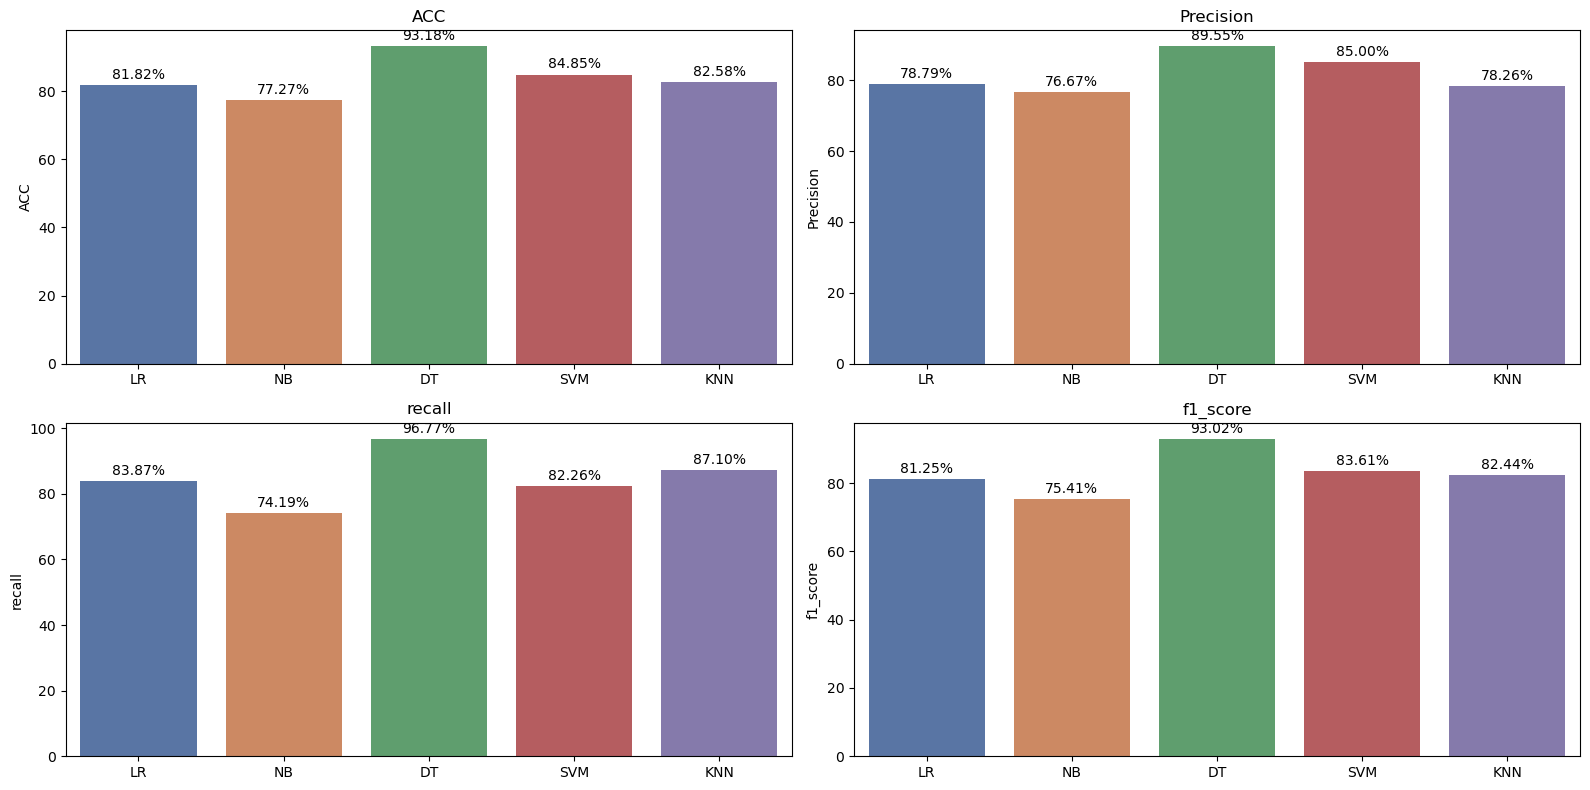

In [108]:

# models = data_Norm.index.values
# per_meaures = data_Norm.columns[:]
# n_cols = 2
# n_rows = math.ceil(len(per_meaures) / n_cols)

# plt.figure(figsize=(12,8))


# for i , col in enumerate(per_meaures, 1):

#      plt.subplot(n_rows, n_rows , i)
#      sns.barplot(x=models, y=data_Norm[col], palette="deep")
#      for line in range(len(x)):
#           plt.text(line-0.37, # x
#                 50, # y
#                "{:.2f}%".format(y[line]), 
#                 horizontalalignment='left',
#                fontsize=12,
#                color="white",
#                )
 
    
# plt.tight_layout()

# plt.show()

#########################################################

models = data_Norm.index.values
per_meaures = data_Norm.columns[:]

n_cols = 2
n_rows = math.ceil(len(per_meaures) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(per_meaures, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=models, y=data_Norm[col], palette="deep")
    
    x = range(len(models))
    y = data_Norm[col].values
    for j in x:
        plt.text(j, y[j] + max(y)*0.01,  # وضع النص أعلى البار
                 "{:.2f}%".format(y[j]),
                 ha='center', va='bottom',
                 color="black",
                 fontsize=10)

    plt.title(col)
    plt.tight_layout()  

plt.show()

## **compare between all models** *`with Standard Data`*

In [109]:
standard = [df_s , df_s2, df_s3, df_s4, df_s5]

data_Stand = pd.concat(standard)
data_Stand

,ACC,Precision,recall,f1_score
LR,85.61,84.13,85.48,84.80
NB,77.27,76.67,74.19,75.41
DT,93.18,89.55,96.77,93.02
SVM,86.36,83.33,88.71,85.94
KNN,84.85,82.81,85.48,84.13


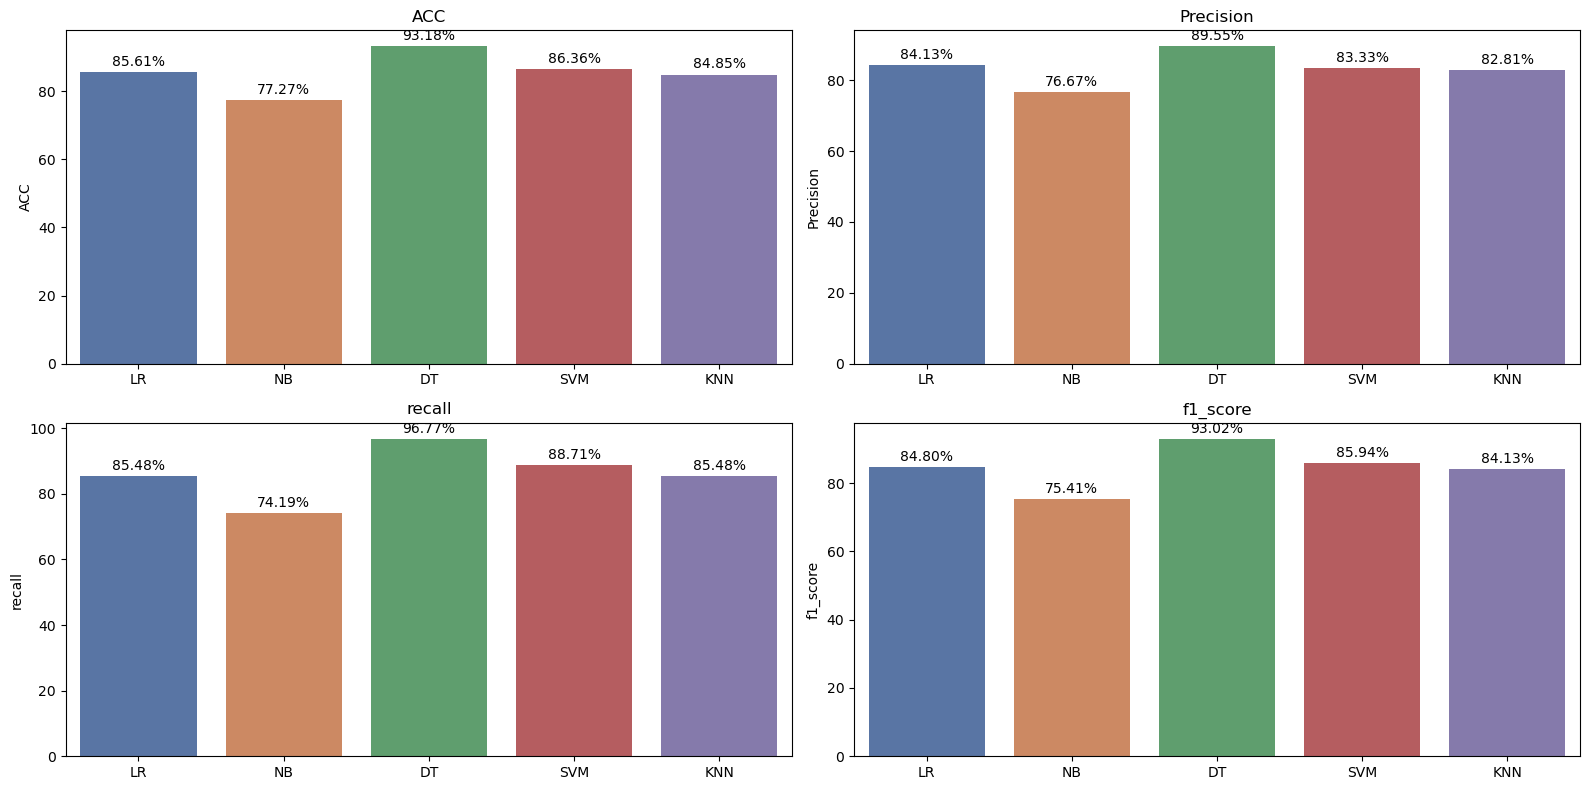

In [110]:

models = data_Stand.index.values
per_meaures = data_Stand.columns[:]

n_cols = 2
n_rows = math.ceil(len(per_meaures) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(per_meaures, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=models, y=data_Stand[col], palette="deep")
    
    x = range(len(models))
    y = data_Stand[col].values
    for j in x:
        plt.text(j, y[j] + max(y)*0.01,  # وضع النص أعلى البار
                 "{:.2f}%".format(y[j]),
                 ha='center', va='bottom',
                 color="black",
                 fontsize=10)

    plt.title(col)
    plt.tight_layout()  

plt.show()

## **Cross-Validation**

In [116]:

models = {
    "LR": LogisticRegression(),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(max_depth=8),
    "SVM": SVC(),
    "KNN" : KNeighborsClassifier() 
}

In [117]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro',
}

In [118]:
path = 'heart_disease_data.csv'
data = pd.read_csv(path)
x = StandardScaler().fit_transform(data[['cp','thalach', 'slope', 'exang', 'oldpeak', 'ca', 'thal']])
x = np.asarray(x)
y = np.asarray(data['target'])

perf_resualt = []
for name, model in models.items():
    results = cross_validate(model, x, y, cv=9, scoring=scoring)
    
    perf_resualt.append({
        'Accuracy': round(results['test_accuracy'].mean()*100, 2),
        'Precision': round(results['test_precision'].mean()*100, 2),
        'Recall': round(results['test_recall'].mean()*100, 2),
        'F1_Score': round(results['test_f1'].mean()*100, 2)
    })
    

C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Albahr Tecnology\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be 

In [119]:
results_df = pd.DataFrame(perf_resualt , index = ['LR', 'NB', 'DT', 'SVM', 'KNN'])
results_df

,Accuracy,Precision,Recall,F1_Score
LR,83.81,84.44,83.32,83.39
NB,82.00,82.22,81.66,81.71
DT,94.73,94.86,94.63,94.69
SVM,87.61,88.12,87.18,87.35
KNN,86.12,86.33,85.74,85.88


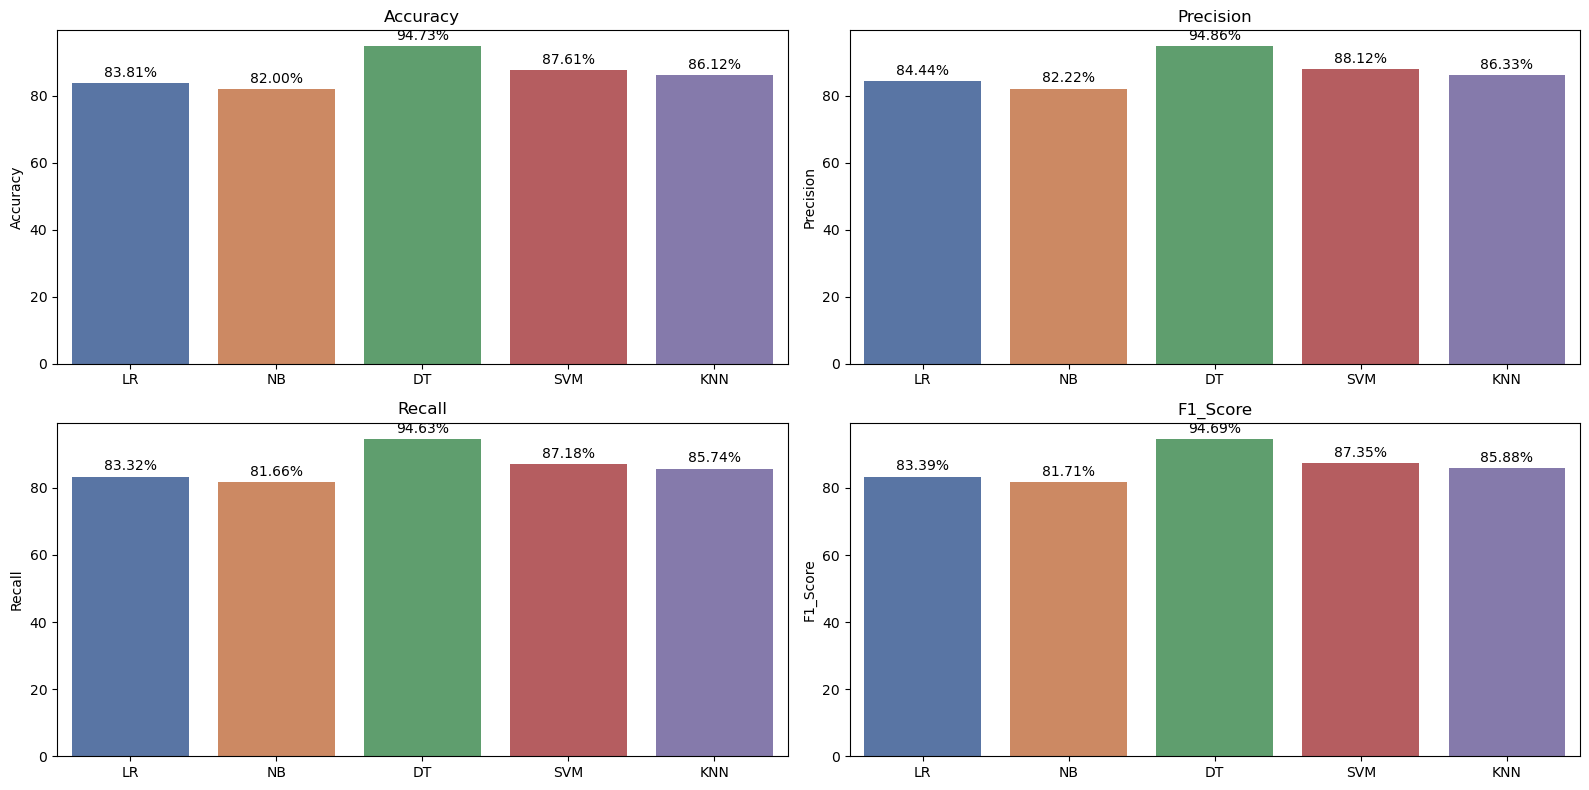

In [120]:

models = results_df.index.values
per_meaures = results_df.columns[:]

n_cols = 2
n_rows = math.ceil(len(per_meaures) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(per_meaures, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=models, y=results_df[col], palette="deep")
    
    x = range(len(models))
    y = results_df[col].values
    for j in x:
        plt.text(j, y[j] + max(y)*0.01,  # وضع النص أعلى البار
                 "{:.2f}%".format(y[j]),
                 ha='center', va='bottom',
                 color="black",
                 fontsize=10)

    plt.title(col)
    plt.tight_layout()  

plt.show()